In [17]:
# ── Bibliothèques ──────────────────────────────────────────
import os
import sys
import django
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [18]:
# ── Configuration Django ───────────────────────────────────
sys.path.insert(0, r'C:\Users\rwenc\Documents\SSMI\medical_system')
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'medical_system.settings')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

django.setup()

print("Django configuré avec succès !")

Django configuré avec succès !


In [20]:
# ── Extraction de toutes les maladies depuis PostgreSQL ────
from apps.dossiers.models import DossierMedical
from django.db.models import Count
from django.db.models.functions import TruncDate

# Extraire toutes les consultations jour par jour par maladie
serie_toutes = DossierMedical.objects.annotate(
    date=TruncDate('date_consultation')
).values('date', 'diagnostic').annotate(
    nombre=Count('id')
).order_by('diagnostic', 'date')

# Convertir en DataFrame
df_all = pd.DataFrame(list(serie_toutes))
df_all['date'] = pd.to_datetime(df_all['date'])

print(f"Nombre total de lignes : {len(df_all)}")
print(f"Nombre de maladies distinctes : {df_all['diagnostic'].nunique()}")
print(f"\nTop 10 maladies :")
print(df_all.groupby('diagnostic')['nombre'].sum().sort_values(ascending=False).head(10))

Nombre total de lignes : 1440
Nombre de maladies distinctes : 8

Top 10 maladies :
diagnostic
Paludisme          990
Grippe             721
Gastro-entérite    447
Bronchite          446
Angine             362
Asthme             362
Diabète            355
Hypertension       355
Name: nombre, dtype: int64


In [21]:
# ── Préparer les séries par maladie ───────────────────────

# Garder uniquement les maladies avec au moins 10 consultations
maladies_suffisantes = df_all.groupby('diagnostic')['nombre'].sum()
maladies_selectionnees = maladies_suffisantes[
    maladies_suffisantes >= 100
].index.tolist()

print(f"Maladies sélectionnées : {maladies_selectionnees}")

# Créer une série complète pour chaque maladie
series_par_maladie = {}

for maladie in maladies_selectionnees:
    df_maladie = df_all[df_all['diagnostic'] == maladie].copy()
    df_maladie = df_maladie.set_index('date')
    df_maladie = df_maladie[['nombre']].resample('D').sum()
    df_maladie['nombre'] = df_maladie['nombre'].astype(float)
    df_maladie['nombre'] = df_maladie['nombre'].replace(0, float('nan')).interpolate(method='linear')
    df_maladie['nombre'] = df_maladie['nombre'].round().astype(int)
    series_par_maladie[maladie] = df_maladie

    print(f"{maladie} : {len(df_maladie)} jours")

Maladies sélectionnées : ['Angine', 'Asthme', 'Bronchite', 'Diabète', 'Gastro-entérite', 'Grippe', 'Hypertension', 'Paludisme']
Angine : 180 jours
Asthme : 180 jours
Bronchite : 180 jours
Diabète : 180 jours
Gastro-entérite : 180 jours
Grippe : 180 jours
Hypertension : 180 jours
Paludisme : 180 jours


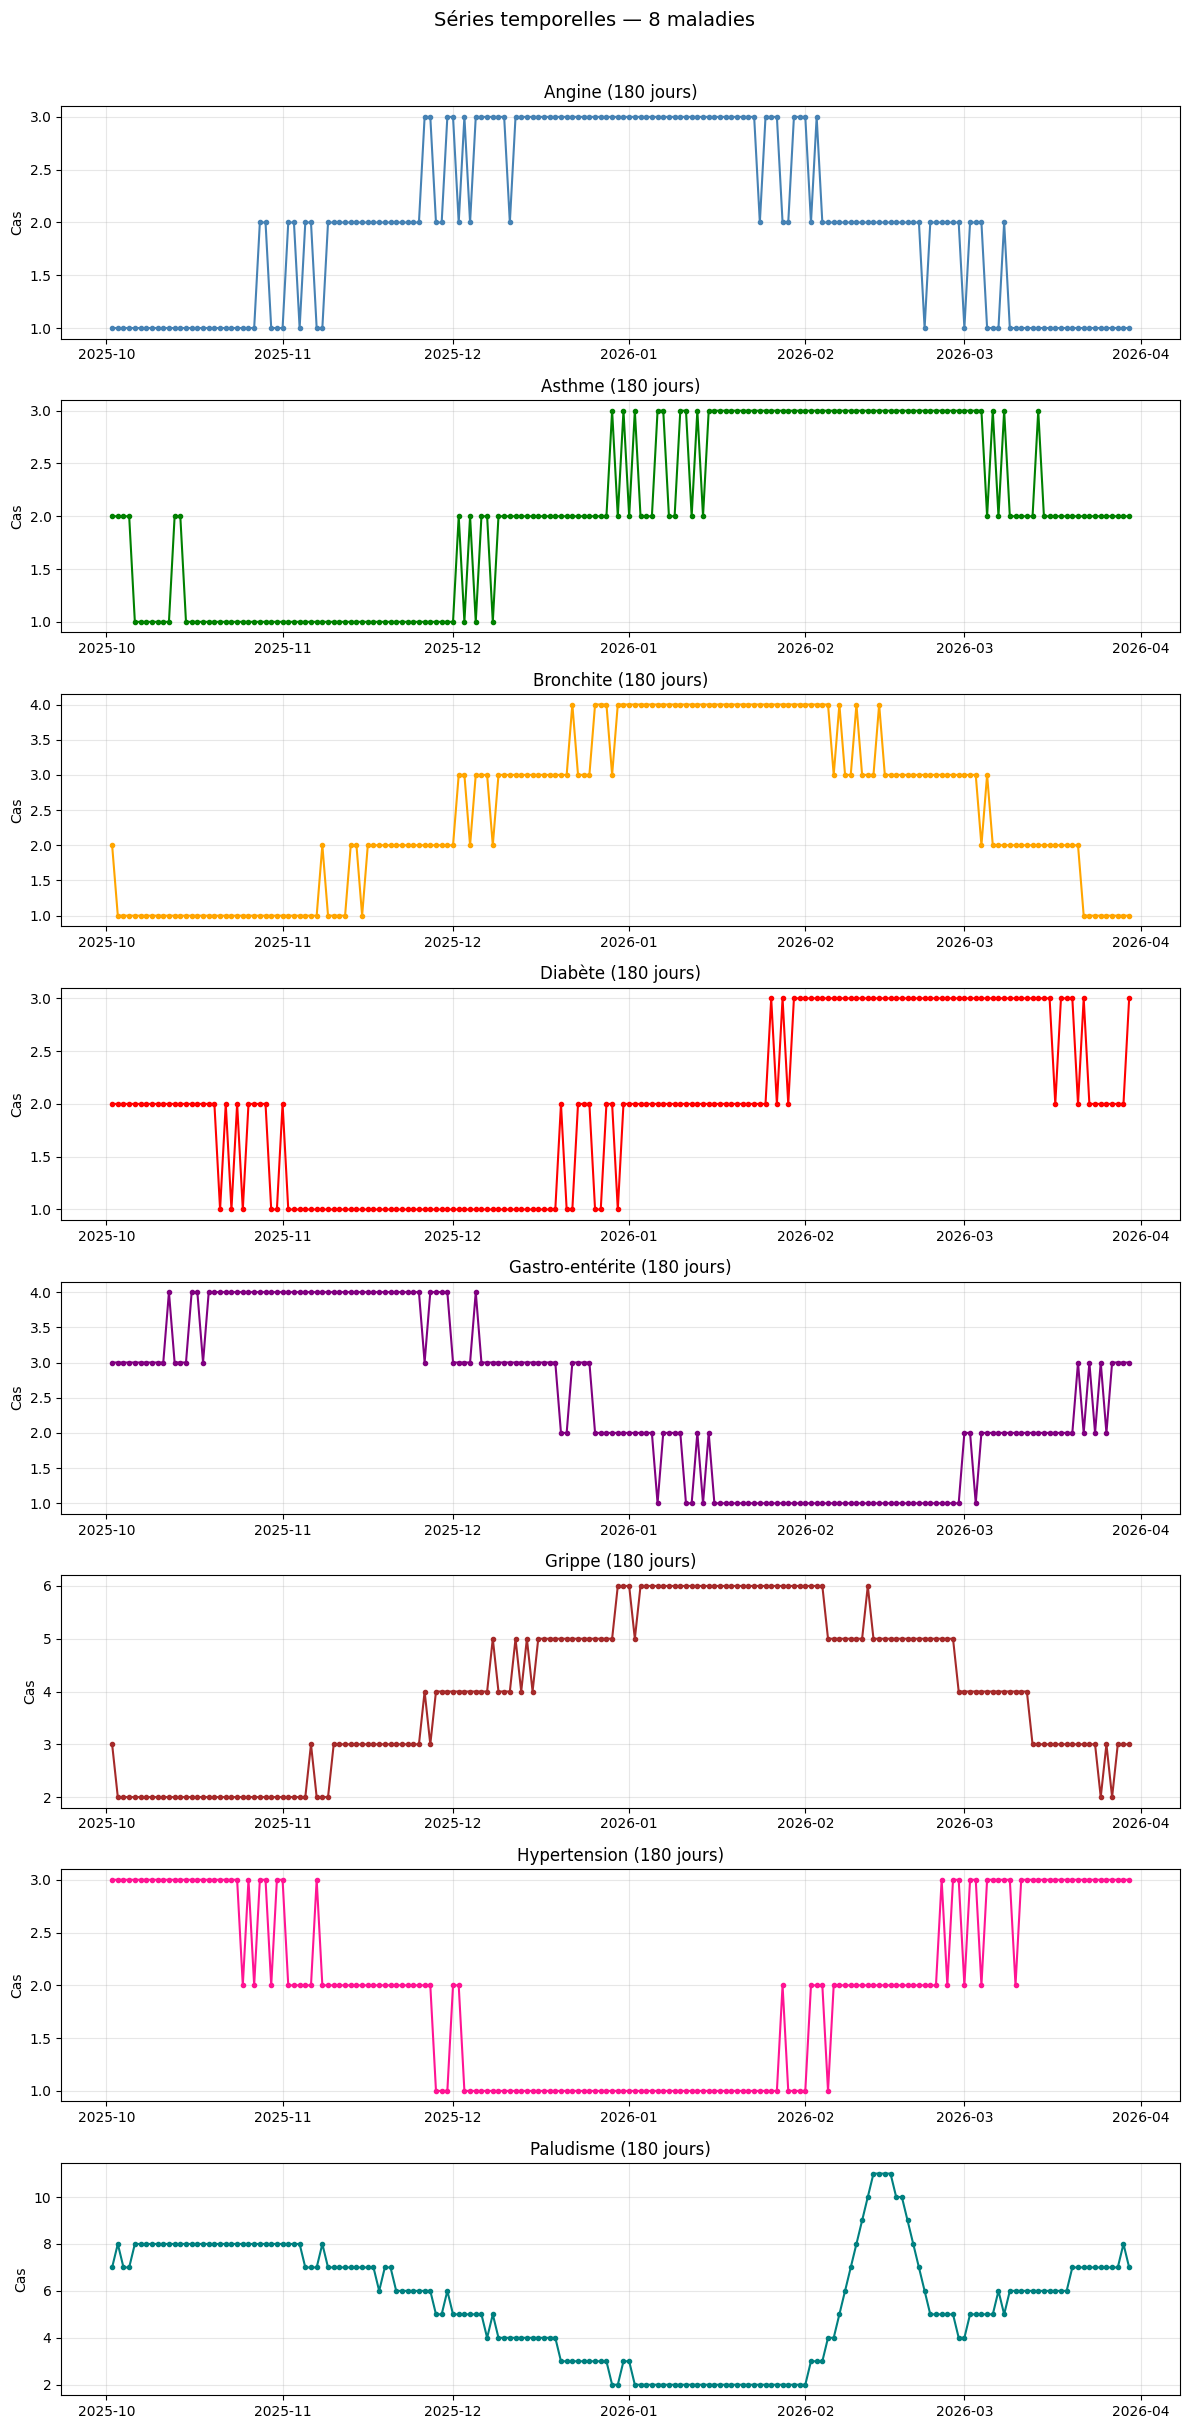

In [23]:
# ── Visualiser les 8 séries temporelles ───────────────────

fig, axes = plt.subplots(8, 1, figsize=(12, 24))

couleurs = ['steelblue', 'green', 'orange', 'red', 
            'purple', 'brown', 'deeppink', 'teal']

for i, (maladie, couleur) in enumerate(
    zip(maladies_selectionnees, couleurs)
):
    df_maladie = series_par_maladie[maladie]
    axes[i].plot(df_maladie.index, df_maladie['nombre'],
                 marker='o', color=couleur,
                 linewidth=1.5, markersize=3)
    axes[i].set_title(f'{maladie} ({len(df_maladie)} jours)')
    axes[i].set_ylabel('Cas')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Séries temporelles — 8 maladies', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

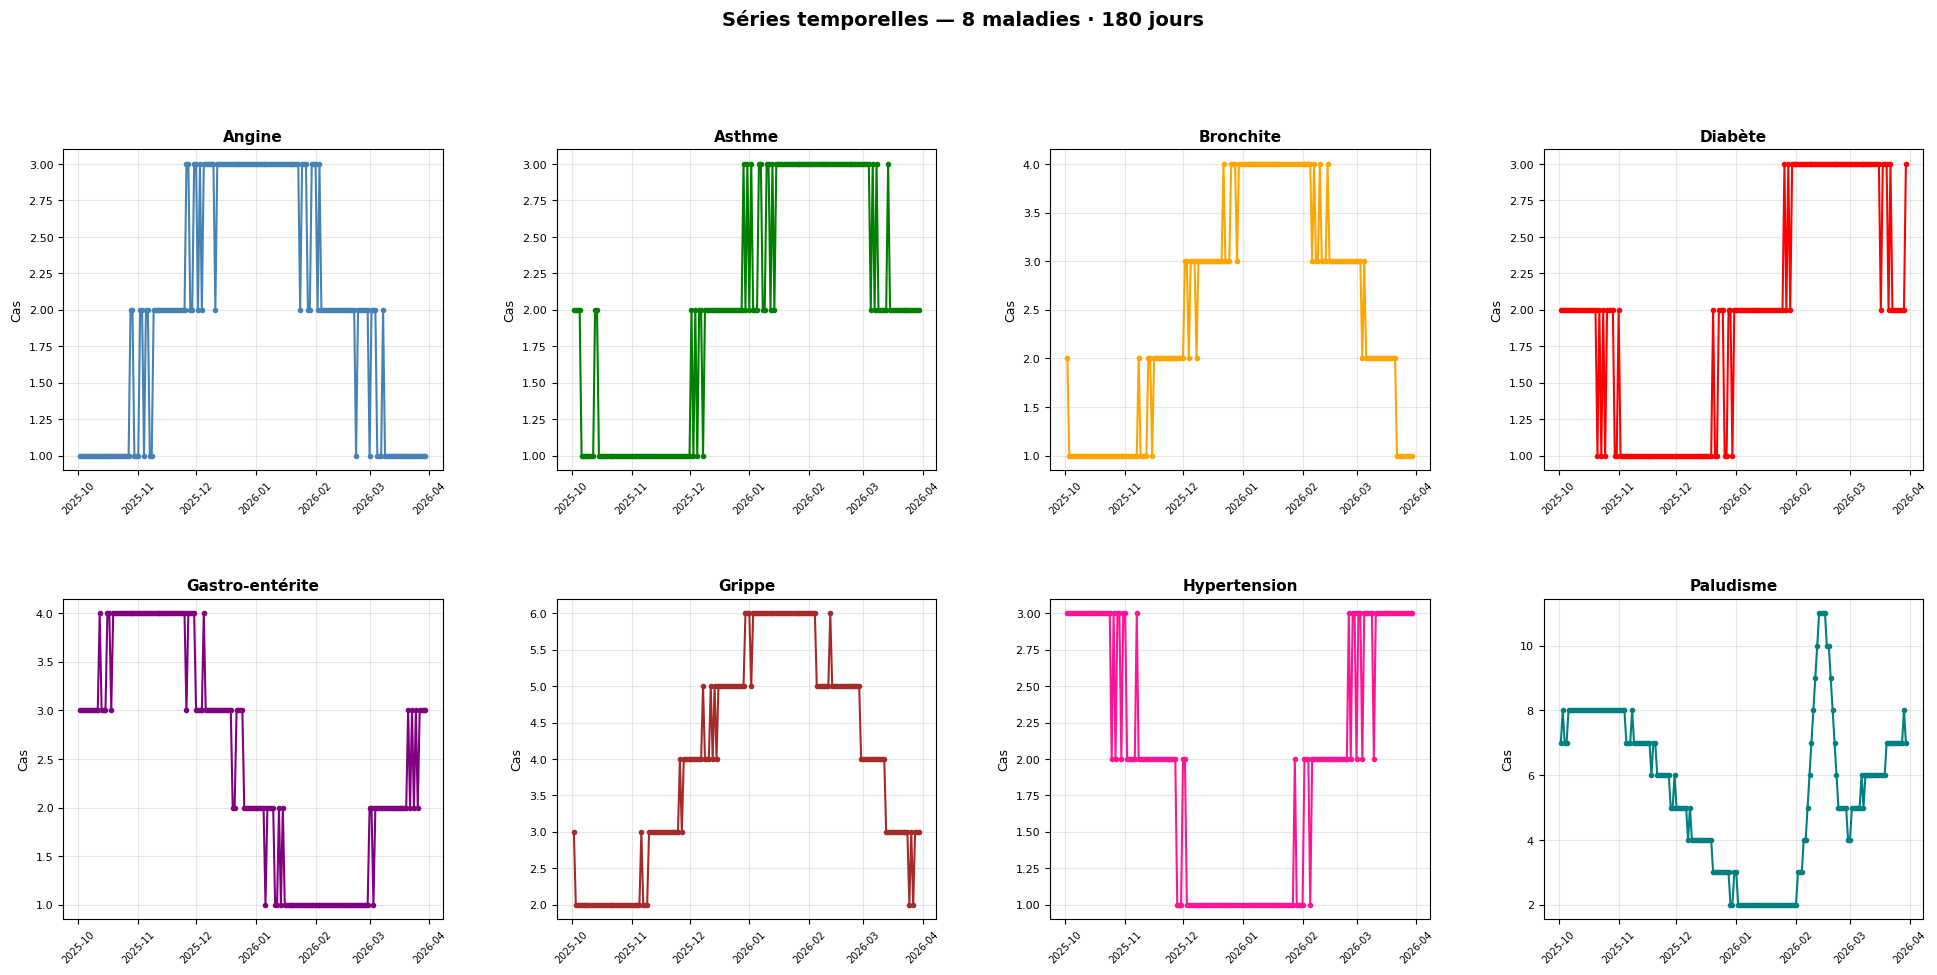

Graphique sauvegardé !


In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 10))

couleurs = ['steelblue', 'green', 'orange', 'red',
            'purple', 'brown', 'deeppink', 'teal']

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)

for i, (maladie, couleur) in enumerate(zip(maladies_selectionnees, couleurs)):
    row = i // 4
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    df_maladie = series_par_maladie[maladie]
    ax.plot(df_maladie.index, df_maladie['nombre'],
            marker='o', color=couleur,
            linewidth=1.5, markersize=3)
    ax.set_title(f'{maladie}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cas', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Séries temporelles — 8 maladies · 180 jours',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('series_8_maladies_landscape.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Graphique sauvegardé !")

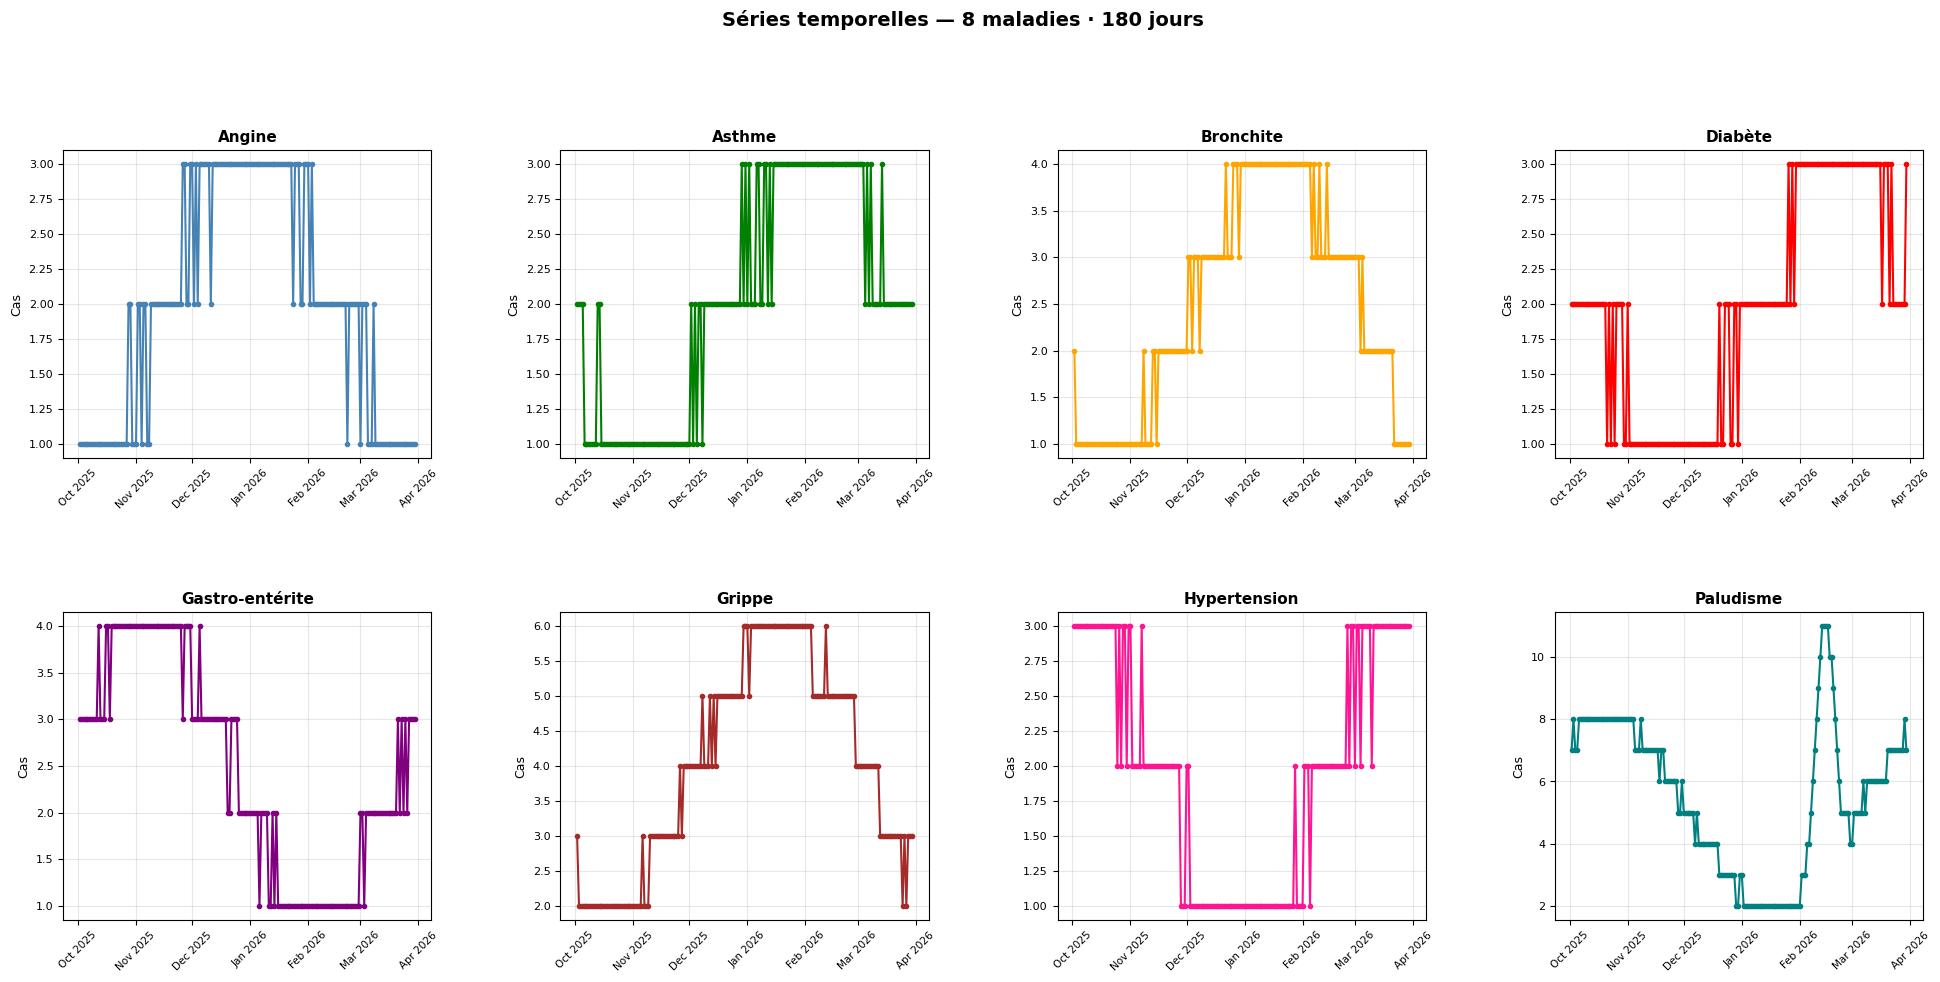

Graphique sauvegardé !


In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

fig = plt.figure(figsize=(24, 10))

couleurs = ['steelblue', 'green', 'orange', 'red',
            'purple', 'brown', 'deeppink', 'teal']

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)

for i, (maladie, couleur) in enumerate(zip(maladies_selectionnees, couleurs)):
    row = i // 4
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    df_maladie = series_par_maladie[maladie]
    ax.plot(df_maladie.index, df_maladie['nombre'],
            marker='o', color=couleur,
            linewidth=1.5, markersize=3)
    ax.set_title(f'{maladie}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cas', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Forcer 6 étiquettes propres sur l'axe X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7.5)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Séries temporelles — 8 maladies · 180 jours',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('series_8_maladies_landscape.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Graphique sauvegardé !")

In [24]:
# ── Normalisation et préparation pour le TimeGAN ──────────

scalers = {}
sequences_all = []
taille_sequence = 7

for maladie in maladies_selectionnees:
    # Normaliser chaque maladie séparément
    valeurs = series_par_maladie[maladie]['nombre'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    valeurs_norm = scaler.fit_transform(valeurs)
    scalers[maladie] = scaler
    
    # Créer les séquences
    for i in range(len(valeurs_norm) - taille_sequence):
        sequences_all.append(valeurs_norm[i:i+taille_sequence])

sequences_all = np.array(sequences_all)

print(f"Nombre total de séquences : {sequences_all.shape[0]}")
print(f"Taille de chaque séquence : {sequences_all.shape[1]} jours")
print(f"Forme finale : {sequences_all.shape}")

Nombre total de séquences : 1384
Taille de chaque séquence : 7 jours
Forme finale : (1384, 7, 1)


In [25]:
# ── TimeGAN : Générateur + Discriminateur ─────────────────

# ── Générateur ────────────────────────────────────────────
class Generateur(nn.Module):
    def __init__(self, bruit_dim=32, hidden_size=64, seq_len=7):
        super(Generateur, self).__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.fc_entree = nn.Linear(bruit_dim, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, 
                           num_layers=2, batch_first=True)
        self.fc_sortie = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, bruit):
        x = self.fc_entree(bruit)
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm(x)
        x = self.fc_sortie(x)
        return self.sigmoid(x)

# ── Discriminateur ────────────────────────────────────────
class Discriminateur(nn.Module):
    def __init__(self, hidden_size=64, seq_len=7):
        super(Discriminateur, self).__init__()
        self.lstm = nn.LSTM(1, hidden_size, 
                           num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# ── Initialiser les modèles ───────────────────────────────
generateur = Generateur(bruit_dim=32, hidden_size=64, seq_len=7)
discriminateur = Discriminateur(hidden_size=64, seq_len=7)

print("Générateur :")
print(generateur)
print(f"\nDiscriminateur :")
print(discriminateur)

Générateur :
Generateur(
  (fc_entree): Linear(in_features=32, out_features=64, bias=True)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (fc_sortie): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Discriminateur :
Discriminateur(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [26]:
# ── TimeGAN amélioré ──────────────────────────────────────

# Réinitialiser les modèles
generateur = Generateur(bruit_dim=32, hidden_size=64, seq_len=7)
discriminateur = Discriminateur(hidden_size=64, seq_len=7)

# Nouveaux paramètres
lr = 0.0001          # Réduit de 0.0002 à 0.0001
epochs = 1000        # Augmenté de 500 à 1000
batch_size = 16

optimizer_G = torch.optim.Adam(generateur.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(discriminateur.parameters(), lr=lr)
criterion = nn.BCELoss()

pertes_G = []
pertes_D = []

for epoch in range(epochs):
    discriminateur.train()
    generateur.train()

    # Vraies données
    idx = np.random.randint(0, len(X_tensor), batch_size)
    vraies_donnees = X_tensor[idx]

    # Fausses données
    bruit = torch.randn(batch_size, 32)
    fausses_donnees = generateur(bruit)

    # Labels
    vrais_labels = torch.ones(batch_size, 1)
    faux_labels = torch.zeros(batch_size, 1)

    # ── Entraîner le Discriminateur 1 fois ───────────────
    pred_vraies = discriminateur(vraies_donnees)
    pred_fausses = discriminateur(fausses_donnees.detach())
    perte_D = criterion(pred_vraies, vrais_labels) + \
              criterion(pred_fausses, faux_labels)

    optimizer_D.zero_grad()
    perte_D.backward()
    optimizer_D.step()

    # ── Entraîner le Générateur 2 fois ───────────────────
    for _ in range(2):
        bruit = torch.randn(batch_size, 32)
        fausses_donnees = generateur(bruit)
        pred_fausses = discriminateur(fausses_donnees)
        perte_G = criterion(pred_fausses, vrais_labels)

        optimizer_G.zero_grad()
        perte_G.backward()
        optimizer_G.step()

    pertes_G.append(perte_G.item())
    pertes_D.append(perte_D.item())

    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}/1000 — Perte G : {perte_G.item():.4f} — Perte D : {perte_D.item():.4f}")

print("\nEntraînement terminé !")

Epoch 200/1000 — Perte G : 0.6932 — Perte D : 1.3885
Epoch 400/1000 — Perte G : 0.6983 — Perte D : 1.4080
Epoch 600/1000 — Perte G : 0.7633 — Perte D : 1.3958
Epoch 800/1000 — Perte G : 0.7273 — Perte D : 1.4024
Epoch 1000/1000 — Perte G : 0.7546 — Perte D : 1.3638

Entraînement terminé !


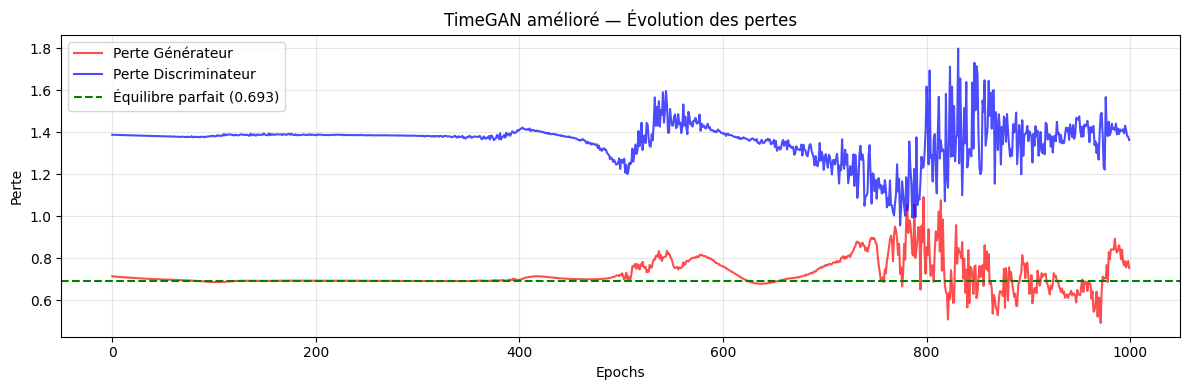

In [27]:
# ── Visualiser les nouvelles pertes ───────────────────────

plt.figure(figsize=(12, 4))
plt.plot(pertes_G, label='Perte Générateur', color='red', alpha=0.7)
plt.plot(pertes_D, label='Perte Discriminateur', color='blue', alpha=0.7)
plt.axhline(y=0.693, color='green', linestyle='--',
            label='Équilibre parfait (0.693)')
plt.title('TimeGAN amélioré — Évolution des pertes')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# ── Générer 10 séries synthétiques ────────────────────────

generateur.eval()
nb_series = 10

with torch.no_grad():
    bruit = torch.randn(nb_series, 32)
    series_synthetiques = generateur(bruit).numpy()

# Dénormaliser avec le scaler du Paludisme
scaler_paludisme = scalers['Paludisme']
series_denorm = []

for serie in series_synthetiques:
    serie_denorm = scaler_paludisme.inverse_transform(serie)
    serie_denorm = np.round(serie_denorm).astype(int)
    serie_denorm = np.clip(serie_denorm, 0, None)
    series_denorm.append(serie_denorm.flatten())

# Afficher
print("10 séries synthétiques générées (7 jours chacune) :\n")
for i, serie in enumerate(series_denorm):
    print(f"Série {i+1} : {serie}")

10 séries synthétiques générées (7 jours chacune) :

Série 1 : [4 3 4 7 8 8 8]
Série 2 : [2 2 2 2 2 2 2]
Série 3 : [2 2 2 2 2 2 2]
Série 4 : [2 2 2 3 9 9 9]
Série 5 : [ 2  2  2  2  3  9 10]
Série 6 : [ 2  2  2  2  3  9 10]
Série 7 : [2 2 2 2 2 2 2]
Série 8 : [ 2  2  2  3  9 10  9]
Série 9 : [8 8 8 8 8 8 8]
Série 10 : [3 2 4 8 9 9 9]


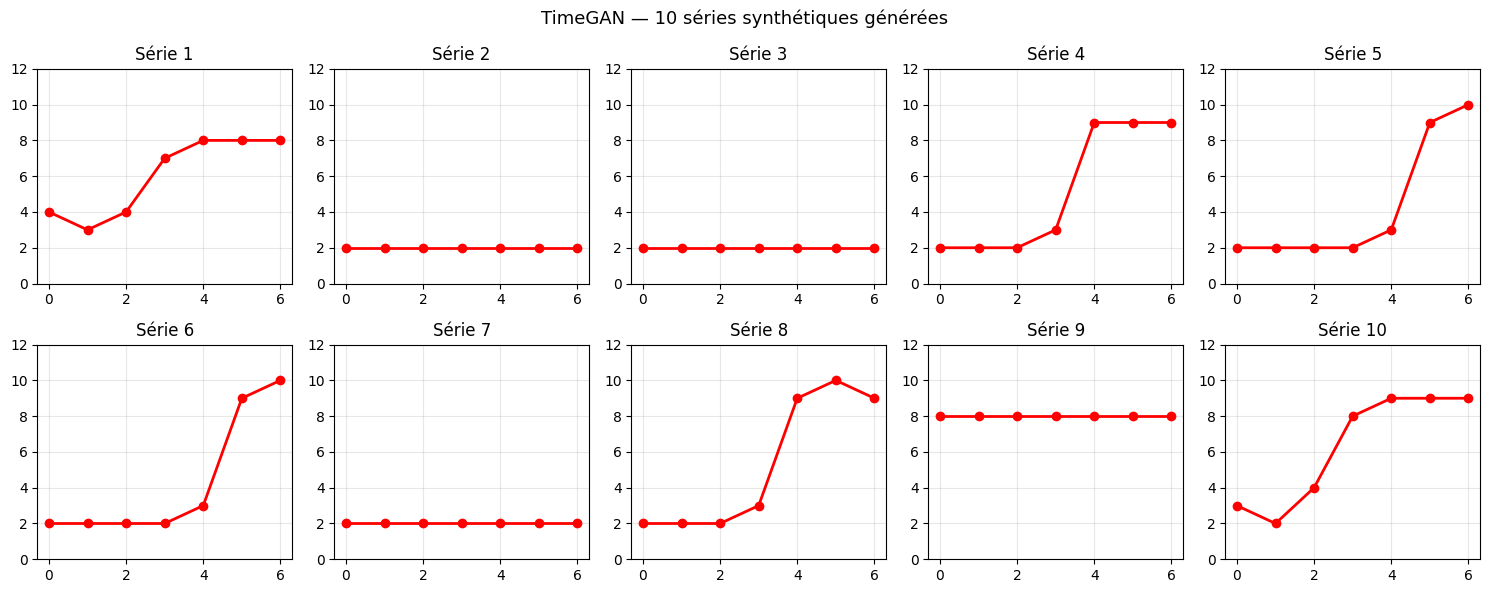

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, serie in enumerate(series_denorm):
    axes[i].plot(serie, marker='o', color='red', linewidth=2)
    axes[i].set_title(f'Série {i+1}')
    axes[i].set_ylim(0, 12)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('TimeGAN — 10 séries synthétiques générées', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# ── Métriques d'évaluation ─────────────────────────────────
import numpy as np
from scipy.stats import ks_2samp

def calculer_mmd(X_reel, X_genere, sigma=1.0):
    """
    Maximum Mean Discrepancy
    Plus proche de 0 = données générées similaires aux vraies
    """
    def rbf_kernel(X, Y, sigma):
        XX = np.sum(X**2, axis=1, keepdims=True)
        YY = np.sum(Y**2, axis=1, keepdims=True)
        XY = np.dot(X, Y.T)
        distances = XX + YY.T - 2*XY
        return np.exp(-distances / (2 * sigma**2))
    
    K_XX = rbf_kernel(X_reel, X_reel, sigma)
    K_YY = rbf_kernel(X_genere, X_genere, sigma)
    K_XY = rbf_kernel(X_reel, X_genere, sigma)
    
    mmd = K_XX.mean() + K_YY.mean() - 2*K_XY.mean()
    return mmd

def calculer_dtw(serie1, serie2):
    """
    Dynamic Time Warping
    Mesure la similarité entre deux séries temporelles
    Plus proche de 0 = séries similaires
    """
    n, m = len(serie1), len(serie2)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(serie1[i-1] - serie2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    return dtw_matrix[n, m]

print("Fonctions MMD et DTW définies !")

Fonctions MMD et DTW définies !


In [31]:
# ── Calcul des métriques MMD et DTW ───────────────────────

# 1. Prendre des vraies séries pour comparaison
vraies_series = sequences_all[:10].reshape(10, 7)

# 2. Générer 10 nouvelles séries synthétiques
generateur.eval()
with torch.no_grad():
    bruit = torch.randn(10, 32)
    series_synthetiques_norm = generateur(bruit).numpy().reshape(10, 7)

# 3. Calculer MMD
mmd_score = calculer_mmd(vraies_series, series_synthetiques_norm)
print(f"Score MMD : {mmd_score:.6f}")
print(f"Interprétation MMD : ", end="")
if mmd_score < 0.01:
    print("Excellent — distributions très similaires")
elif mmd_score < 0.05:
    print("Bon — distributions similaires")
elif mmd_score < 0.1:
    print("Acceptable — différences modérées")
else:
    print("A améliorer — distributions différentes")

# 4. Calculer DTW moyen
dtw_scores = []
for i in range(10):
    score = calculer_dtw(vraies_series[i], series_synthetiques_norm[i])
    dtw_scores.append(score)

dtw_moyen = np.mean(dtw_scores)
print(f"\nScore DTW moyen : {dtw_moyen:.4f}")
print(f"Interprétation DTW : ", end="")
if dtw_moyen < 0.5:
    print("Excellent — formes très similaires")
elif dtw_moyen < 1.0:
    print("Bon — formes similaires")
elif dtw_moyen < 2.0:
    print("Acceptable — différences modérées")
else:
    print("A améliorer — formes différentes")

# 5. Tableau récapitulatif
print("\n" + "="*40)
print("RÉSUMÉ DES MÉTRIQUES")
print("="*40)
print(f"MMD  : {mmd_score:.6f}")
print(f"DTW  : {dtw_moyen:.4f}")
print("="*40)

Score MMD : 0.715699
Interprétation MMD : A améliorer — distributions différentes

Score DTW moyen : 2.6751
Interprétation DTW : A améliorer — formes différentes

RÉSUMÉ DES MÉTRIQUES
MMD  : 0.715699
DTW  : 2.6751


In [32]:
import os
import torch

# Créer le dossier de sauvegarde
os.makedirs('models', exist_ok=True)

# Sauvegarder le TimeGAN
torch.save(generateur.state_dict(), 
           'models/timegan_generateur.pth')
torch.save(discriminateur.state_dict(), 
           'models/timegan_discriminateur.pth')

# Sauvegarder les scalers
import pickle
with open('models/scalers_timegan.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Modèles TimeGAN sauvegardés !")
print("  models/timegan_generateur.pth")
print("  models/timegan_discriminateur.pth")
print("  models/scalers_timegan.pkl")

Modèles TimeGAN sauvegardés !
  models/timegan_generateur.pth
  models/timegan_discriminateur.pth
  models/scalers_timegan.pkl
